### Perform Clustering

In [1]:
# Imports
import numpy as np
import os, sys
import matplotlib.pyplot as plt

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
from clustering import Cluster
from yaml_processor import load_config, save_config
from data_processing import load_dataset, save_dataset, parameter_plot

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)

##### Initialization

In [2]:
# Minimum number of data points in each cluster
min_data_per_cluster = 16

In [3]:
dataset_path = os.path.join(output_dir, "datasets")
SS_train, param_train = load_dataset(os.path.join(dataset_path, "Train"))
SS_val, param_val = load_dataset(os.path.join(dataset_path, "Val"))
SS_test, param_test = load_dataset(os.path.join(dataset_path, "Test"))

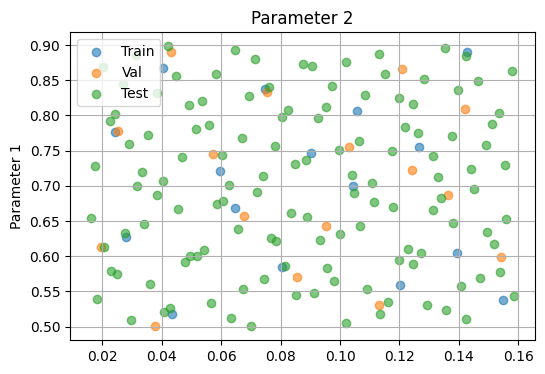

In [4]:
parameter_plot(param_train, param_val, param_test)

Choose Clustering Method - (hierarchical, kmeans, dbscan, agglomerative, spectral)

In [5]:
method = "hierarchical"

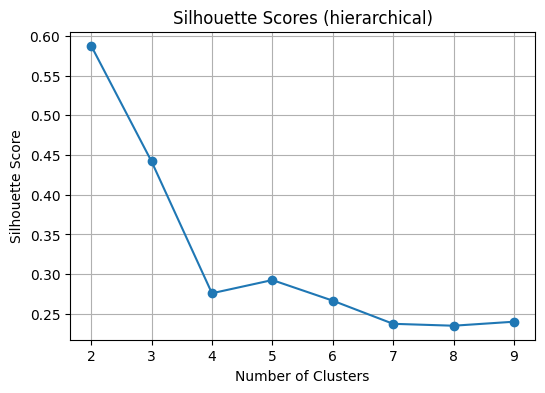

k=2, silhouette=0.588
k=3, silhouette=0.442
k=4, silhouette=0.276
k=5, silhouette=0.293
k=6, silhouette=0.267
k=7, silhouette=0.238
k=8, silhouette=0.235
k=9, silhouette=0.240


In [6]:
clust = Cluster(SS_train[:, 1], param_train) # clustering using velocity data
sil_scores = clust.find_best_k_by_silhouette(method=method, k_range=range(2, 10))

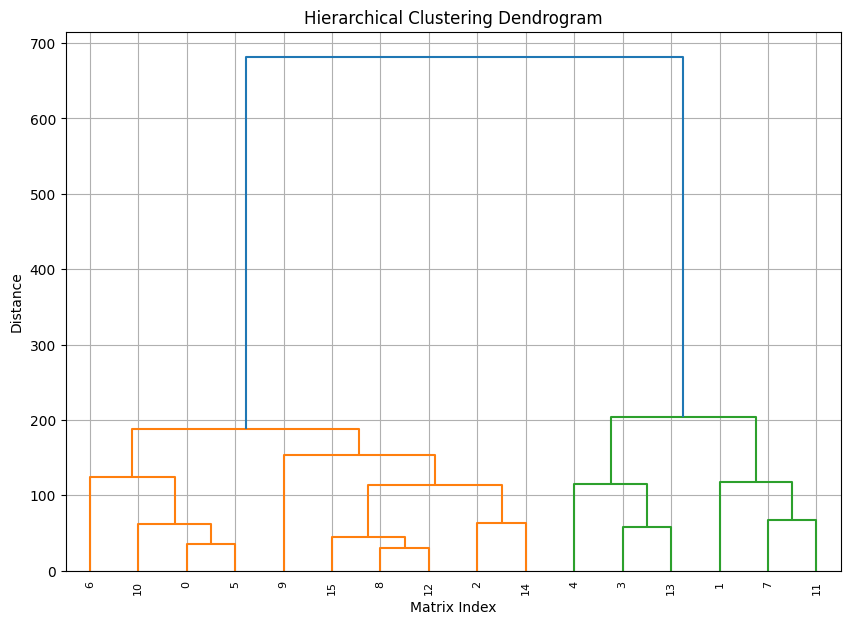

In [7]:
clust.plot_dendrogram()

Choose optimal number of clusters

In [8]:
n_clusters = 2

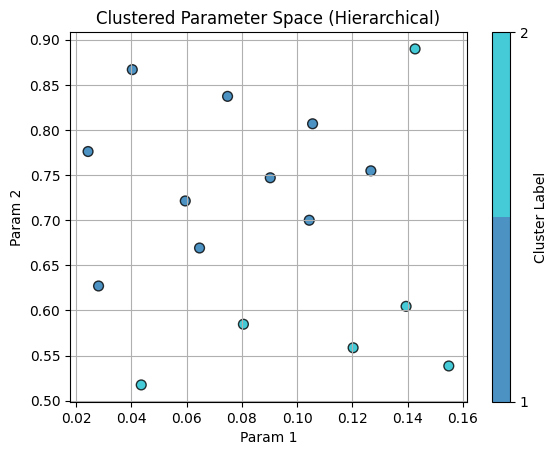

In [9]:
clust.find_clusters(method=method, n_clusters=n_clusters)
clust.plot_clusters_2d()

##### Fill Missing Cluster Data

In [10]:
NLS_cl, param_cl, param_idx = clust.get_clustered_data()

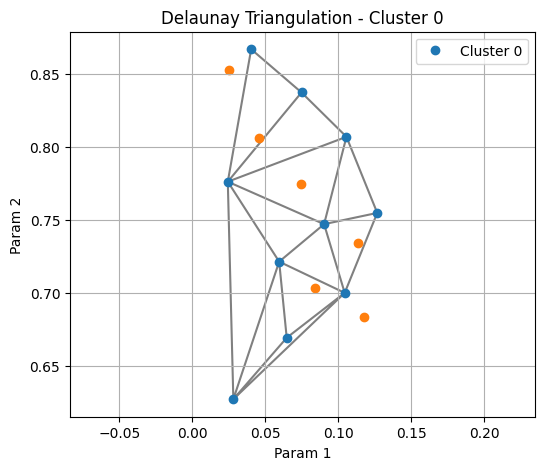

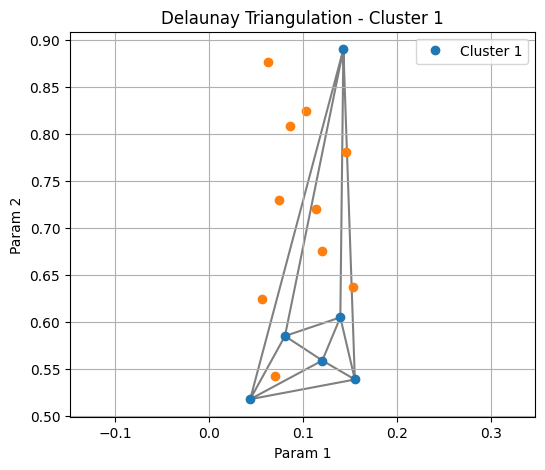

In [ ]:
for cluster in range(len(param_idx)):
    if len(param_idx[cluster]) < min_data_per_cluster:
        new_params = clust.generate_from_cluster(cluster_idx=cluster, n_samples=min_data_per_cluster-len(param_idx[cluster]), param_gen="kde", min_dist=0.02)
        np.concatenate([param_train, new_params], axis=0)

In [12]:
new_params

array([[0.14620975, 0.61854449],
       [0.09889726, 0.65320165],
       [0.08953751, 0.57497748],
       [0.10389665, 0.65662746],
       [0.1350073 , 0.55741515],
       [0.13190626, 0.55927197],
       [0.11004913, 0.69921859],
       [0.06645043, 0.55445919],
       [0.1268166 , 0.7186437 ],
       [0.1122161 , 0.59759269]])

In [13]:
print(param_idx[1])

[1, 3, 4, 7, 11, 13]


In [24]:
test = np.array([1,2])

In [25]:
(test != None)

array([ True,  True])

In [ ]:
type.

AttributeError: type object 'type' has no attribute 'NoneType'